In [12]:
import pdfplumber
import pandas as pd

PDF_PATH = r"D:\PC DISAINE\toky\Perso-D\red\momo\transaction-history-20260707_140107415.pdf"  # change to your file path

all_tables = []

with pdfplumber.open(PDF_PATH) as pdf:
    for i, page in enumerate(pdf.pages):
        table = page.extract_table()
        if table:
            print(f"Page {i+1}: found table with {len(table)-1} rows")
            all_tables.append(table)

# Use first table found, or merge all
raw = all_tables[0]
df = pd.DataFrame(raw[1:], columns=raw[0])  # row 0 = headers
df.head()

Page 1: found table with 13 rows
Page 2: found table with 17 rows
Page 3: found table with 17 rows
Page 4: found table with 17 rows
Page 5: found table with 17 rows
Page 6: found table with 16 rows
Page 7: found table with 16 rows
Page 8: found table with 18 rows
Page 9: found table with 16 rows
Page 10: found table with 17 rows
Page 11: found table with 19 rows
Page 12: found table with 19 rows
Page 13: found table with 17 rows
Page 14: found table with 17 rows
Page 15: found table with 17 rows
Page 16: found table with 15 rows


,Transaction\nId,Status,Transaction Type,Date,From,To,Amount (RWF),Fee\n(RWF),Balance\nAfter\n(RWF)
0,28998423642,SUCCESSFUL,PAYMENT,2026-07-05 17:05:47,250798654398\nAwet Tsegay\nGEBREYOHANNES,38998332\nRED IKIRWA\nFLAVOURS Ltd RED\nIKIRWA...,8000,N/A,1464157
1,28997739812,SUCCESSFUL,LAST_TRANSACTIONS,2026-07-05 16:33:29,250795573441\nRED IKIRWA FLAVOURS Ltd,N/A,0,0,1456197
2,28996685391,SUCCESSFUL,PAYMENT,2026-07-05 15:39:39,250780612861\nTOROITICH PATRICIA\nNGONYO,38998332\nRED IKIRWA\nFLAVOURS Ltd RED\nIKIRWA...,6000,N/A,1456197
3,28996598783,SUCCESSFUL,PAYMENT,2026-07-05 15:34:37,250794920982\nChris Lumiere MAFAFARI,38998332\nRED IKIRWA\nFLAVOURS Ltd RED\nIKIRWA...,5000,N/A,1450227
4,28996375148,SUCCESSFUL,PAYMENT,2026-07-05 15:23:19,250787186147\nNICOLE KANYANA,38998332\nRED IKIRWA\nFLAVOURS Ltd RED\nIKIRWA...,46000,N/A,1445252


# Clean raw tabular data

In [13]:
headers = all_tables[0][0]
frames = []

for t in all_tables:
    rows = [row for row in t if row != headers]  # drop repeated header rows
    frames.append(pd.DataFrame(rows, columns=headers))

df = pd.concat(frames, ignore_index=True)

df = df.replace("", pd.NA)
df = df.dropna(how="any")

df = df.rename(columns={'Amount\n(RWF)': 'Amount (RWF)'})

df['Amount (RWF)'] = df['Amount (RWF)'].astype(int)

df.shape

(257, 9)

In [14]:
df["Date"] = pd.to_datetime(df["Date"], format="%Y-%m-%d %H:%M:%S")
start = pd.to_datetime("2026-07-05 00:00:00")
end   = pd.to_datetime("2026-07-05 23:59:59")

df_subset = df[(df["Date"] >= start) & (df["Date"] <= end)]
df_subset.shape

(24, 9)

# Calculate the sum of all transactions

In [15]:
# Assign +/- sign based on the type column
df_subset["Signed Amount"] = df_subset["Amount (RWF)"].where(df_subset["Transaction Type"] == "PAYMENT", -df_subset["Amount (RWF)"])

# Then sum
total_transactions = df_subset["Signed Amount"].sum()
print(total_transactions)

228000


## Total fees

In [16]:
balance_2026_06_18 = 1237396
balance_2026_06_19 = 1464157

total_actual_transactions = balance_2026_06_19 - balance_2026_06_18
print(total_actual_transactions)

226761


In [17]:
error = 0
total_fees = total_transactions - total_actual_transactions - error

print(total_fees)

1239


# Check individual transaction fee

In [18]:
df_subset = df_subset.rename(columns={'Balance\nAfter\n(RWF)': 'Balance'})
df_subset["Balance"] = df_subset["Balance"].astype("int")

In [19]:
df_subset["transaction_fee"] = df_subset["Amount (RWF)"] - ( df_subset["Balance"] - df_subset["Balance"].shift(-1) )


In [20]:
total = df_subset.loc[(df_subset["transaction_fee"] >= 0) & (df_subset["transaction_fee"] <= 3000), "transaction_fee"].sum()
print(total)

1239.0


In [21]:
df_subset

,Transaction\nId,Status,Transaction Type,Date,From,To,Amount (RWF),Fee\n(RWF),Balance,Signed Amount,transaction_fee
0,28998423642,SUCCESSFUL,PAYMENT,2026-07-05 17:05:47,250798654398\nAwet Tsegay\nGEBREYOHANNES,38998332\nRED IKIRWA\nFLAVOURS Ltd RED\nIKIRWA...,8000,N/A,1464157,8000,40.0
1,28997739812,SUCCESSFUL,LAST_TRANSACTIONS,2026-07-05 16:33:29,250795573441\nRED IKIRWA FLAVOURS Ltd,N/A,0,0,1456197,0,0.0
2,28996685391,SUCCESSFUL,PAYMENT,2026-07-05 15:39:39,250780612861\nTOROITICH PATRICIA\nNGONYO,38998332\nRED IKIRWA\nFLAVOURS Ltd RED\nIKIRWA...,6000,N/A,1456197,6000,30.0
3,28996598783,SUCCESSFUL,PAYMENT,2026-07-05 15:34:37,250794920982\nChris Lumiere MAFAFARI,38998332\nRED IKIRWA\nFLAVOURS Ltd RED\nIKIRWA...,5000,N/A,1450227,5000,25.0
4,28996375148,SUCCESSFUL,PAYMENT,2026-07-05 15:23:19,250787186147\nNICOLE KANYANA,38998332\nRED IKIRWA\nFLAVOURS Ltd RED\nIKIRWA...,46000,N/A,1445252,46000,230.0
5,28996235541,SUCCESSFUL,PAYMENT,2026-07-05 15:15:35,250787322662\nOlivier NKURUNZIZA,38998332\nRED IKIRWA\nFLAVOURS Ltd RED\nIKIRWA...,6000,N/A,1399482,6000,30.0
6,28996202530,SUCCESSFUL,PAYMENT,2026-07-05 15:14:13,250787322662\nOlivier NKURUNZIZA,38998332\nRED IKIRWA\nFLAVOURS Ltd RED\nIKIRWA...,2000,N/A,1393512,2000,10.0
7,28995099766,SUCCESSFUL,PAYMENT,2026-07-05 14:18:05,250790137628\nMeseker Mekuria MARRU,38998332\nRED IKIRWA\nFLAVOURS Ltd RED\nIKIRWA...,6500,N/A,1391522,6500,32.0
8,28994184978,SUCCESSFUL,PAYMENT,2026-07-05 13:33:10,250789406249\nAHMED YOUSFI,38998332\nRED IKIRWA\nFLAVOURS Ltd RED\nIKIRWA...,4000,N/A,1385054,4000,20.0
9,28993864201,SUCCESSFUL,PAYMENT,2026-07-05 13:16:57,250781616432\nBEN ABSDALLAH ALAA,38998332\nRED IKIRWA\nFLAVOURS Ltd RED\nIKIRWA...,35000,N/A,1381074,35000,175.0


# Check the wallet movement

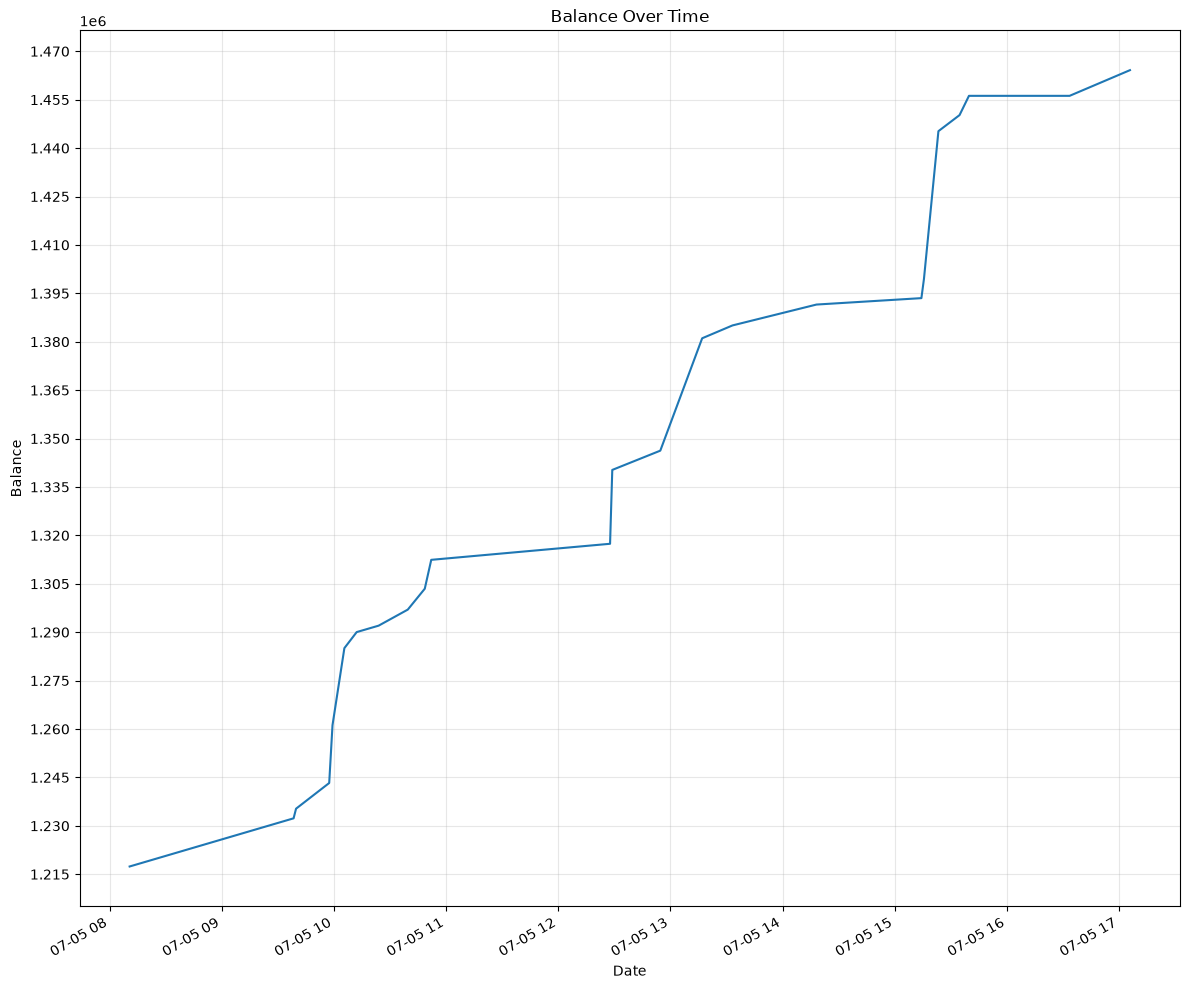

In [22]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import pandas as pd

# Convert the date column to datetime (adjust 'Date' to your actual column name)
df_subset['Date'] = pd.to_datetime(df_subset['Date'])

# Sort by date so the line plots in chronological order
df_subset = df_subset.sort_values('Date')

plt.figure(figsize=(12, 10))
plt.plot(df_subset['Date'], df_subset['Balance'])
plt.title('Balance Over Time')
plt.xlabel('Date')
plt.ylabel('Balance')
plt.grid(True, alpha=0.3)

plt.gca().yaxis.set_major_locator(ticker.MaxNLocator(nbins=20))

plt.gcf().autofmt_xdate()  # rotates and aligns the date labels nicely
plt.tight_layout()
plt.show()